# Level 2 + LightGBM

基於 `level2.ipynb`（Single Model，GBM AUC=0.7051）改用 LightGBM：
- Leaf-wise 生長，通常比 sklearn GBM 更強
- `scale_pos_weight` 處理 18:82 不平衡
- 速度快 10 倍，可以跑更多 trees
- 架構完全相同（Single Model + Contact feature），方便 apple-to-apple 比較

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
from lightgbm import LGBMClassifier, LGBMRegressor
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['font.size'] = 12

In [5]:
# ============================================================
# 1. 載入資料
# ============================================================

def load_and_clean(path):
    df = pd.read_csv(path, low_memory=False, encoding='utf-8-sig')
    df.columns = df.columns.str.strip().str.strip('"')
    for col in df.columns:
        if df[col].dtype == object:
            df[col] = df[col].str.strip().str.strip('"')
    num_cols = ['Contact', 'GaveThisYear', 'AmtThisYear', 'Woman', 'Age', 'Salary',
                'SeniorList', 'NbActivities', 'Referrals', 'Recency', 'Frequency',
                'Seniority', 'TotalGift', 'MinGift', 'MaxGift', 'GaveLastYear', 'AmtLastYear']
    for col in num_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    return df

train = load_and_clean('data/表格_FUNDRAISE_R2_TRAIN.csv')
train = train.dropna(subset=['Contact', 'GaveThisYear', 'AmtThisYear']).reset_index(drop=True)
print(f'R2_TRAIN: {train.shape}')
print(f'捐款率: {train["GaveThisYear"].mean():.2%}, 不平衡比: {(1-train["GaveThisYear"].mean())/train["GaveThisYear"].mean():.1f}:1')

R2_TRAIN: (100000, 22)
捐款率: 20.32%, 不平衡比: 3.9:1


In [6]:
# ============================================================
# 2. 前處理 & 切分
# ============================================================

DROP_COLS = ['ID', 'LastName', 'FirstName', 'GaveThisYear', 'AmtThisYear']
CAT_COLS  = ['Education', 'City']

def preprocess(df, feature_cols=None):
    out = df.drop(columns=[c for c in DROP_COLS if c in df.columns], errors='ignore')
    out = pd.get_dummies(out, columns=[c for c in CAT_COLS if c in out.columns], drop_first=True)
    if feature_cols is not None:
        for col in feature_cols:
            if col not in out.columns:
                out[col] = 0
        out = out[feature_cols]
    return out

X_all    = preprocess(train)
y_cls    = train['GaveThisYear'].astype(int)
y_amt    = train['AmtThisYear']
feature_cols = X_all.columns.tolist()

X_train, X_val, y_cls_train, y_cls_val, y_amt_train, y_amt_val = train_test_split(
    X_all, y_cls, y_amt, test_size=0.2, random_state=42, stratify=y_cls
)

neg, pos = (y_cls_train == 0).sum(), (y_cls_train == 1).sum()
scale_pos = neg / pos
print(f'特徵數: {len(feature_cols)}')
print(f'scale_pos_weight: {scale_pos:.2f}  (neg={neg:,}, pos={pos:,})')

特徵數: 20
scale_pos_weight: 3.92  (neg=63,748, pos=16,252)


In [7]:
# ============================================================
# 3. LightGBM 分類模型
# ============================================================

clf_lgbm = LGBMClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    num_leaves=63,           # 2^6 - 1，leaf-wise 比 depth-wise 更細緻
    subsample=0.8,
    colsample_bytree=0.8,    # 每棵樹隨機選 80% 特徵
    min_child_samples=20,
    scale_pos_weight=scale_pos,  # 處理不平衡
    reg_alpha=0.1,           # L1 正則化
    reg_lambda=0.1,          # L2 正則化
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

clf_lgbm.fit(
    X_train, y_cls_train,
    eval_set=[(X_val, y_cls_val)],
    callbacks=[]
)

y_proba_val = clf_lgbm.predict_proba(X_val)[:, 1]
auc_lgbm    = roc_auc_score(y_cls_val, y_proba_val)

# 5-fold CV AUC（更穩健的評估）
cv_aucs = []
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for tr_idx, vl_idx in skf.split(X_all, y_cls):
    m = LGBMClassifier(
        n_estimators=500, max_depth=6, learning_rate=0.05, num_leaves=63,
        subsample=0.8, colsample_bytree=0.8, min_child_samples=20,
        scale_pos_weight=scale_pos, reg_alpha=0.1, reg_lambda=0.1,
        random_state=42, n_jobs=-1, verbose=-1
    )
    m.fit(X_all.iloc[tr_idx], y_cls.iloc[tr_idx])
    cv_aucs.append(roc_auc_score(y_cls.iloc[vl_idx], m.predict_proba(X_all.iloc[vl_idx])[:, 1]))

print(f'LightGBM 分類模型:')
print(f'  Holdout AUC:  {auc_lgbm:.4f}')
print(f'  5-fold CV AUC: {np.mean(cv_aucs):.4f} ± {np.std(cv_aucs):.4f}')
print(f'  GBM 基準:      0.7051')
print(f'  提升:          {auc_lgbm - 0.7051:+.4f}')

# Feature importance
fi = pd.Series(clf_lgbm.feature_importances_, index=feature_cols).sort_values(ascending=False)
print(f'\nTop 10 Feature Importance:')
print(fi.head(10).round(1))

LightGBM 分類模型:
  Holdout AUC:  0.6966
  5-fold CV AUC: 0.6977 ± 0.0036
  GBM 基準:      0.7051
  提升:          -0.0085

Top 10 Feature Importance:
Salary          3930
Age             2899
TotalGift       2309
SeniorList      1617
Recency         1216
Referrals       1191
MinGift         1155
MaxGift         1118
NbActivities    1090
Seniority        962
dtype: int32


In [8]:
# ============================================================
# 4. LightGBM 回歸模型
# ============================================================

from sklearn.metrics import r2_score, mean_absolute_error

donor_mask_train = y_amt_train > 0
donor_mask_val   = y_amt_val   > 0

reg_lgbm = LGBMRegressor(
    n_estimators=500, max_depth=6, learning_rate=0.05, num_leaves=63,
    subsample=0.8, colsample_bytree=0.8, min_child_samples=20,
    reg_alpha=0.1, reg_lambda=0.1, random_state=42, n_jobs=-1, verbose=-1
)
reg_lgbm.fit(X_train[donor_mask_train], np.log1p(y_amt_train[donor_mask_train]))

y_pred_log = reg_lgbm.predict(X_val[donor_mask_val])
r2_log  = r2_score(np.log1p(y_amt_val[donor_mask_val]), y_pred_log)
r2_orig = r2_score(y_amt_val[donor_mask_val], np.expm1(y_pred_log).clip(min=0))

print(f'LightGBM 回歸模型:')
print(f'  R² (log space):  {r2_log:.4f}  （GBM 基準: 0.0155）')
print(f'  R² (orig space): {r2_orig:.4f}')

LightGBM 回歸模型:
  R² (log space):  -0.0014  （GBM 基準: 0.0155）
  R² (orig space): -0.0171


LightGBM Uplift 驗證:
  Uplift > 成本: 聯繫 12,053 人, Surplus = $111,050
  真實最佳:      聯繫 19,989 人, Surplus = $173,420
  策略效率: 64.0%  （GBM 基準: 70.3%）


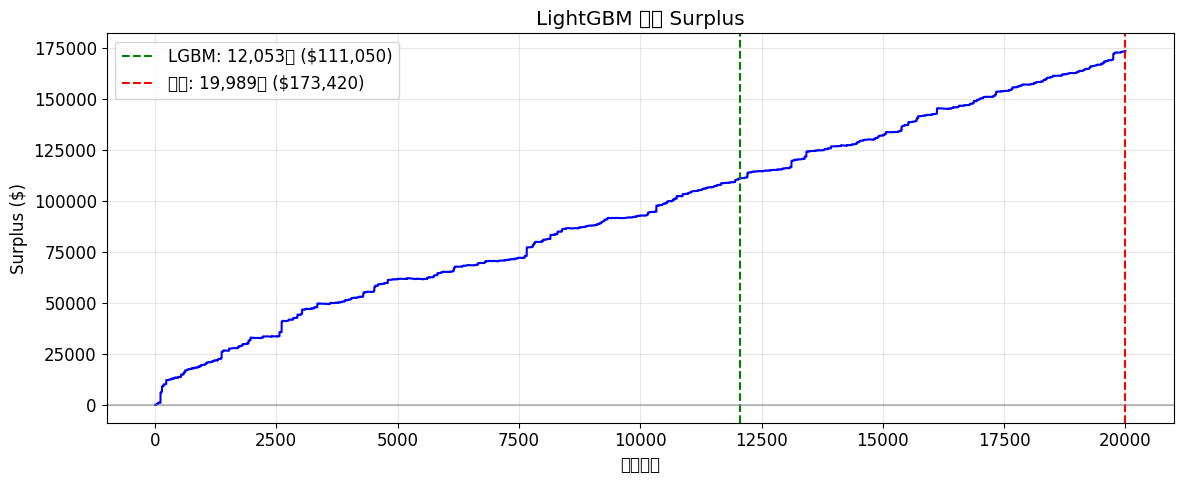

In [9]:
# ============================================================
# 5. Uplift 驗證
# ============================================================

COST_SCHEDULE = [(60_000, 5), (np.inf, 25)]

def calc_total_cost(n, schedule):
    total, remaining, prev = 0, n, 0
    for limit, cost in schedule:
        tier = min(remaining, limit - prev)
        if tier <= 0: break
        total += tier * cost
        remaining -= tier; prev = limit
    return total

def get_marginal_cost(rank, schedule):
    for limit, cost in schedule:
        if rank <= limit: return cost
    return schedule[-1][1]

def score_with_contact(X_df, contact_val, clf, reg):
    Xc = X_df.copy(); Xc['Contact'] = contact_val
    P = clf.predict_proba(Xc)[:, 1]
    E = np.expm1(reg.predict(Xc)).clip(min=0)
    return P, E, P * E

P1_val, E1_val, EV1_val = score_with_contact(X_val, 1, clf_lgbm, reg_lgbm)
P0_val, E0_val, EV0_val = score_with_contact(X_val, 0, clf_lgbm, reg_lgbm)
uplift_val = EV1_val - EV0_val

val_df = pd.DataFrame({
    'uplift': uplift_val, 'actual_amt': y_amt_val.values,
    'EV_nocontact': EV0_val,
}).sort_values('uplift', ascending=False).reset_index(drop=True)

val_df['rank']          = range(1, len(val_df)+1)
val_df['marginal_cost'] = val_df['rank'].apply(lambda r: get_marginal_cost(r, COST_SCHEDULE))
val_df['cum_donation']  = val_df['actual_amt'].cumsum()
val_df['cum_cost']      = val_df['rank'].apply(lambda n: calc_total_cost(n, COST_SCHEDULE))
val_df['cum_surplus']   = val_df['cum_donation'] - val_df['cum_cost']

our_n        = (val_df['uplift'] > val_df['marginal_cost']).sum()
our_surplus  = val_df.loc[our_n-1, 'cum_surplus'] if our_n > 0 else 0
best_n       = val_df['cum_surplus'].idxmax() + 1
best_surplus = val_df['cum_surplus'].max()

print(f'LightGBM Uplift 驗證:')
print(f'  Uplift > 成本: 聯繫 {our_n:,} 人, Surplus = ${our_surplus:,.0f}')
print(f'  真實最佳:      聯繫 {best_n:,} 人, Surplus = ${best_surplus:,.0f}')
print(f'  策略效率: {our_surplus/best_surplus:.1%}  （GBM 基準: 70.3%）')

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(val_df['rank'], val_df['cum_surplus'], 'b-', lw=1.5)
ax.axvline(our_n,  color='green', ls='--', label=f'LGBM: {our_n:,}人 (${our_surplus:,.0f})')
ax.axvline(best_n, color='red',   ls='--', label=f'最佳: {best_n:,}人 (${best_surplus:,.0f})')
ax.axhline(0, color='gray', alpha=0.5)
ax.set_xlabel('聯繫人數'); ax.set_ylabel('Surplus ($)')
ax.set_title('LightGBM 累積 Surplus'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [10]:
# ============================================================
# 6. 全量重訓練 → SCOREDATA 評分
# ============================================================

clf_full = LGBMClassifier(
    n_estimators=500, max_depth=6, learning_rate=0.05, num_leaves=63,
    subsample=0.8, colsample_bytree=0.8, min_child_samples=20,
    scale_pos_weight=scale_pos, reg_alpha=0.1, reg_lambda=0.1,
    random_state=42, n_jobs=-1, verbose=-1
)
clf_full.fit(X_all, y_cls)

donor_mask_all = y_amt > 0
reg_full = LGBMRegressor(
    n_estimators=500, max_depth=6, learning_rate=0.05, num_leaves=63,
    subsample=0.8, colsample_bytree=0.8, min_child_samples=20,
    reg_alpha=0.1, reg_lambda=0.1, random_state=42, n_jobs=-1, verbose=-1
)
reg_full.fit(X_all[donor_mask_all], np.log1p(y_amt[donor_mask_all]))
print('LightGBM 全量模型訓練完成')

score_c  = load_and_clean('data/表格_FUNDRAISE_R2_CONTACT_SCOREDATA.csv')
score_nc = load_and_clean('data/表格_FUNDRAISE_R2_NOCONTACT_SCOREDATA.csv')
assert (score_c['ID'].values == score_nc['ID'].values).all()
score_ids = score_c['ID'].copy()

def score_scoredata(df, clf, reg, feature_cols):
    X = preprocess(df, feature_cols=feature_cols)
    P = clf.predict_proba(X)[:, 1]
    E = np.expm1(reg.predict(X)).clip(min=0)
    return P, E, P * E

P1s, E1s, EV1s = score_scoredata(score_c,  clf_full, reg_full, feature_cols)
P0s, E0s, EV0s = score_scoredata(score_nc, clf_full, reg_full, feature_cols)
uplift_s = EV1s - EV0s

print(f'Uplift: mean=${uplift_s.mean():.2f}, 正={( uplift_s>0).sum():,}, 負={( uplift_s<0).sum():,}')

LightGBM 全量模型訓練完成
Uplift: mean=$6.50, 正=82,267, 負=17,733


In [11]:
# ============================================================
# 7. 四象限分類 & 匯出
# ============================================================

SURE_THING_THRESHOLD = 5

score_df = pd.DataFrame({
    'ID': score_ids.values, 'EV_contact': EV1s, 'EV_nocontact': EV0s, 'uplift': uplift_s,
}).sort_values('uplift', ascending=False).reset_index(drop=True)

score_df['rank']          = range(1, len(score_df)+1)
score_df['marginal_cost'] = score_df['rank'].apply(lambda r: get_marginal_cost(r, COST_SCHEDULE))

def classify(row):
    if row['uplift'] > row['marginal_cost']:                                  return 'Persuadable'
    elif row['EV_nocontact'] > SURE_THING_THRESHOLD and row['uplift'] >= 0:  return 'Sure Thing'
    elif row['uplift'] < 0:                                                   return 'Sleeping Dog'
    else:                                                                      return 'Lost Cause'

score_df['quadrant'] = score_df.apply(classify, axis=1)
contact = score_df[score_df['quadrant'] == 'Persuadable']
n_contact  = len(contact)
total_cost = calc_total_cost(n_contact, COST_SCHEDULE)

print('四象限分布:')
print(score_df['quadrant'].value_counts())
print(f'\n聯繫: {n_contact:,} 人, 預估成本 ${total_cost:,.0f}')
print(f'\n與 GBM Single Model 比較:')
print(f'  GBM:     53,277 人, AUC=0.7051')
print(f'  LGBM:    {n_contact:,} 人, AUC={auc_lgbm:.4f}')

import os
os.makedirs('output', exist_ok=True)
output_path = 'output/level2_lgbm_contact_list.csv'
contact[['ID']].to_csv(output_path, index=False)
print(f'\n已匯出 → {output_path}')

四象限分布:
quadrant
Persuadable     56591
Sure Thing      24706
Sleeping Dog    17733
Lost Cause        970
Name: count, dtype: int64

聯繫: 56,591 人, 預估成本 $282,955

與 GBM Single Model 比較:
  GBM:     53,277 人, AUC=0.7051
  LGBM:    56,591 人, AUC=0.6966

已匯出 → output/level2_lgbm_contact_list.csv
